In [1]:
import pandas as pd

orders = pd.read_csv("../data/raw/orders.csv")
order_products = pd.read_csv("../data/raw/order_products__prior.csv")
products = pd.read_csv("../data/raw/products.csv")




In [2]:
transactions = order_products.merge(orders, on="order_id")
transactions = transactions.merge(products, on="product_id")

In [3]:
transactions.isnull().sum()
transactions.dropna(inplace=True)

In [4]:
user_features = transactions.groupby("user_id").agg(
    total_orders=("order_number", "max"),
    total_products=("product_id", "count"),
    avg_basket_size=("add_to_cart_order", "mean")
).reset_index()


In [5]:
product_features = transactions.groupby("product_id").agg(
    total_sales=("product_id", "count"),
    unique_buyers=("user_id", "nunique"),
    avg_cart_position=("add_to_cart_order", "mean")
).reset_index()


In [6]:
retail = pd.read_excel("../data/raw/online_retail_II.xlsx")

retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"])
retail["date"] = retail["InvoiceDate"].dt.date

daily_sales = retail.groupby(
    ["StockCode", "date"]
)["Quantity"].sum().reset_index()
daily_sales["date"] = pd.to_datetime(daily_sales["date"])
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek
daily_sales["month"] = daily_sales["date"].dt.month


In [7]:
split_date = "2010-09-01"

train = daily_sales[daily_sales["date"] < split_date]
test  = daily_sales[daily_sales["date"] >= split_date]


In [8]:
user_features.to_csv("../data/processed/user_features.csv", index=False)
product_features.to_csv("../data/processed/product_features.csv", index=False)
daily_sales.to_csv("../data/processed/daily_sales.csv", index=False)


<Axes: xlabel='date'>

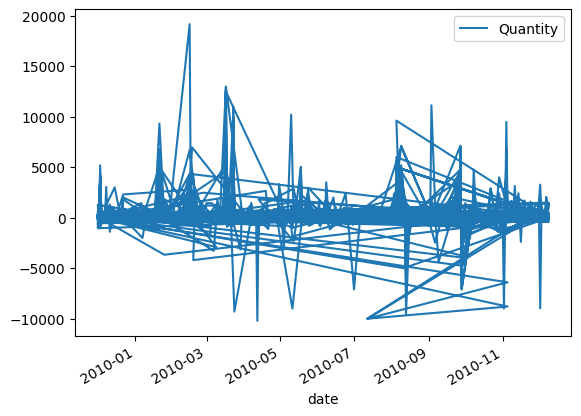

In [9]:
transactions.shape
user_features.describe()
daily_sales.plot(x="date", y="Quantity")


In [10]:
print(len(train), len(test))

179963 92068
